# Instructor Effectiveness Prediction using Machine Learning

# Instructor Effectiveness Modeling

### Data Science Internship Assignment

**Candidate:** Pranjal Pathare

**Objective:**

The objective of this project is to analyze instructor performance using learner outcome, engagement, and feedback metrics. Batch-level data is aggregated into instructor-level information, and a machine learning model is developed to classify instructors into effectiveness tiers.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_excel("instructor_effectiveness_dataset_2000_rows.xlsx")

In [4]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [5]:
df.shape

(2000, 12)

### Dataset Shape

The dataset contains multiple course batches. Each row represents one batch taught by an instructor. The dataset consists of **2000 rows** and **12 columns**, providing learner outcomes, engagement metrics, and feedback information.

In [7]:
df.columns

Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')

### Dataset Features

The dataset contains 12 columns representing batch identifiers, instructor information, learner outcomes, engagement metrics, and learner feedback. These features will be analyzed to understand instructor performance and build a predictive model.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


### Data Types and Missing Values

The dataset contains 2,000 records and 12 columns. Identifier columns such as `batch_id`, `instructor_id`, and `course_id` are stored as text (`object`), while learner outcome, engagement, and feedback metrics are stored as numerical values (`float64`).

The `df.info()` output was used to verify the data types and check for missing values before performing further analysis.

In [9]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

### Missing Value Analysis

Missing values were checked using `df.isnull().sum()`.

The results show that all columns contain complete information with no missing values. Therefore, no missing value treatment or imputation is required before proceeding with the analysis.

In [11]:
df.duplicated().sum()

np.int64(0)

### Duplicate Record Analysis

Duplicate records were checked using `df.duplicated().sum()`.

The dataset contains no duplicate rows, indicating that each batch record is unique. Therefore, no duplicate removal was required.

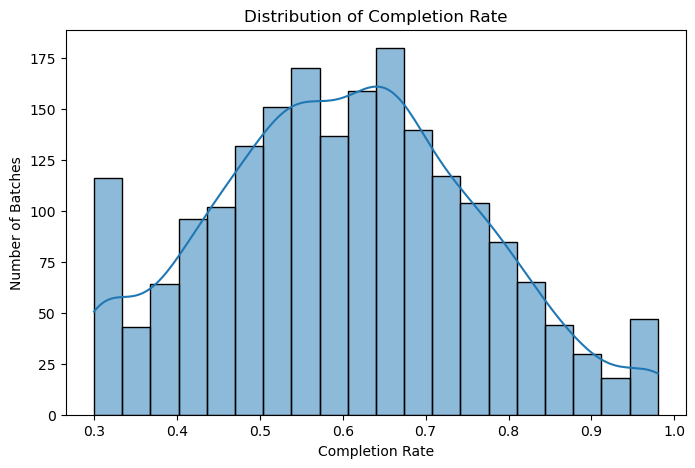

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['completion_rate'], bins=20, kde=True)

plt.title("Distribution of Completion Rate")
plt.xlabel("Completion Rate")
plt.ylabel("Number of Batches")

plt.show()

### Distribution of Completion Rate

A histogram was plotted to visualize how course completion rates are distributed across all batches.

The graph helps identify whether most batches have high or low completion rates and whether the data is evenly distributed or skewed.

**Observation:**

- The completion rates are approximately bell-shaped, with most batches having completion rates between **0.50 and 0.75**.
- The highest concentration of batches is around **0.60–0.70**, indicating that most courses achieve a moderate to high completion rate.
- Very few batches have extremely low completion rates (below 0.40) or extremely high completion rates (above 0.90).
- Overall, the distribution suggests that learner completion is generally satisfactory across most course batches, although there is still room for improvement to achieve consistently higher completion rates.

## Distribution of Dropout Rate

The dropout rate indicates the proportion of learners who discontinued the course before completion. Analyzing its distribution helps identify whether most batches experience low, moderate, or high dropout rates.

A lower dropout rate generally reflects better learner engagement and course effectiveness.

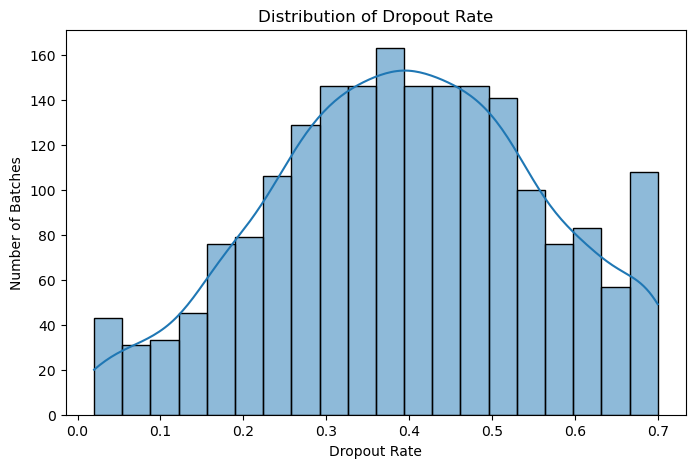

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['dropout_rate'], bins=20, kde=True)

plt.title("Distribution of Dropout Rate")
plt.xlabel("Dropout Rate")
plt.ylabel("Number of Batches")

plt.show()

**Observation:**

- The dropout rates are approximately bell-shaped, with most batches having dropout rates between **0.30 and 0.50**.
- The highest concentration of batches is around **0.35–0.45**, indicating that most courses experience a moderate level of learner dropout.
- Very few batches have extremely low dropout rates (below **0.10**) or very high dropout rates (above **0.60**).
- Since lower dropout rates generally indicate better learner retention, reducing dropout in the higher range could improve overall instructor effectiveness.

## Distribution of Average Quiz Score

The average quiz score reflects learners' academic performance in each course batch. Analyzing its distribution helps determine whether most batches achieve low, moderate, or high quiz performance.

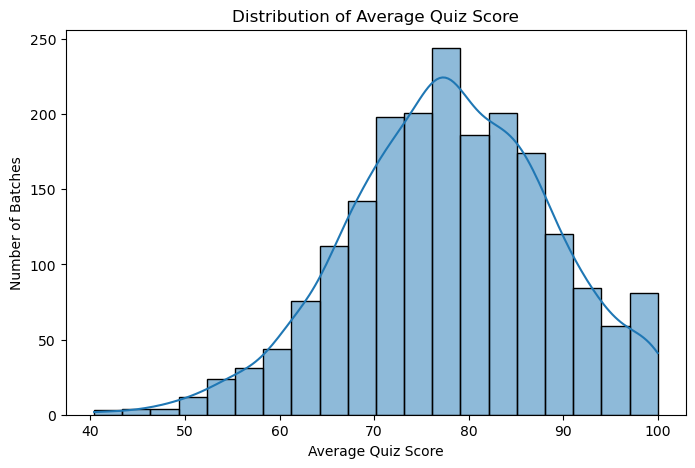

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['avg_quiz_score'], bins=20, kde=True)

plt.title("Distribution of Average Quiz Score")
plt.xlabel("Average Quiz Score")
plt.ylabel("Number of Batches")

plt.show()

**Observation:**

- The average quiz scores follow an approximately normal (bell-shaped) distribution.
- Most course batches have average quiz scores between **70 and 85**, with the highest concentration around **75–80**.
- Only a small number of batches have very low average scores (below **60**) or exceptionally high scores (above **95**).
- The distribution indicates that learners generally perform well in quizzes, suggesting a satisfactory level of knowledge acquisition across most course batches.

# Correlation Analysis

A correlation heatmap was created to examine the relationships between numerical variables in the dataset. Correlation values range from **-1 to +1**, where:

- **+1** indicates a perfect positive relationship.
- **-1** indicates a perfect negative relationship.
- **0** indicates no linear relationship.

The heatmap helps identify which learner outcome, engagement, and feedback metrics are closely related and may influence instructor effectiveness.

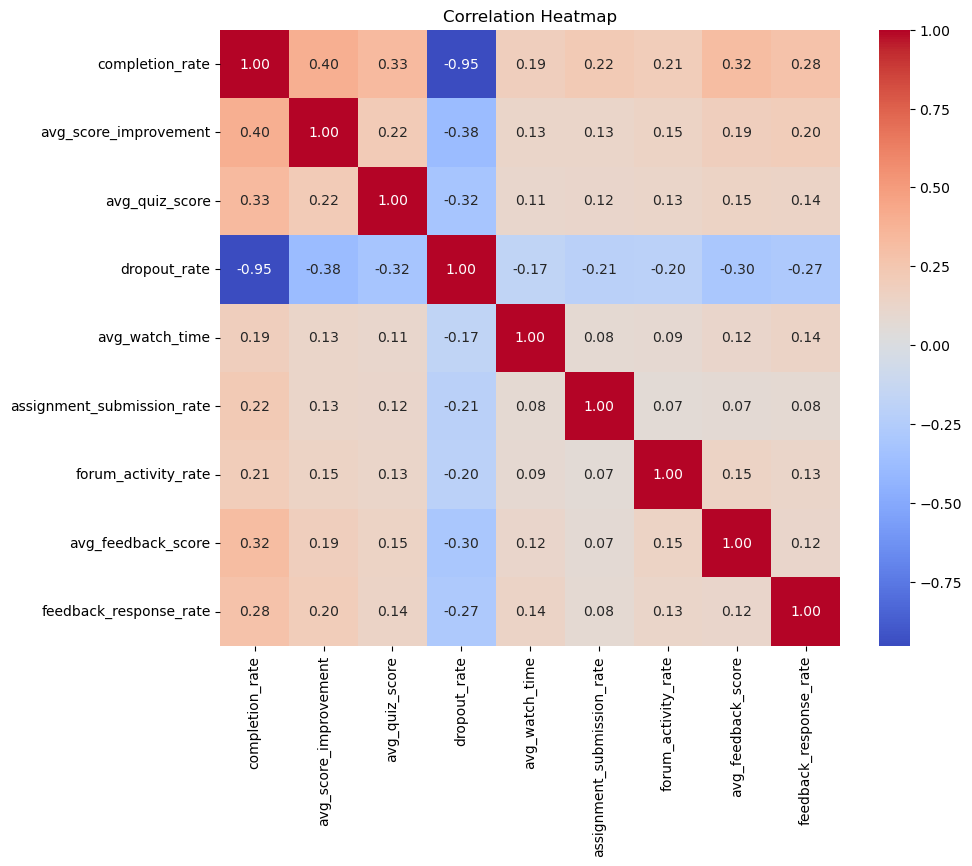

In [15]:
plt.figure(figsize=(10,8))

correlation_matrix = df.drop(columns=['batch_id', 'instructor_id', 'course_id']).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

- **Completion Rate** has a very strong negative correlation (**-0.95**) with **Dropout Rate**, indicating that batches with higher completion rates generally have much lower dropout rates.
- **Completion Rate** has a moderate positive correlation with **Average Score Improvement (0.40)**, suggesting that learners who complete courses tend to show better learning outcomes.
- **Completion Rate** also has positive relationships with **Average Quiz Score (0.33)**, **Average Feedback Score (0.32)**, and **Feedback Response Rate (0.28)**, indicating that better learner performance and satisfaction are associated with higher completion.
- Most engagement metrics, such as **Average Watch Time**, **Assignment Submission Rate**, and **Forum Activity Rate**, show weak positive correlations with other variables, suggesting that they contribute to instructor effectiveness but are not the sole determining factors.
- Overall, learner completion and dropout appear to be the strongest indicators of instructor effectiveness in this dataset.

# Outlier Detection using Boxplots

Boxplots were used to identify potential outliers in the numerical features. Outliers are observations that lie far away from the majority of the data and may represent unusual course batches or exceptional instructor performance.

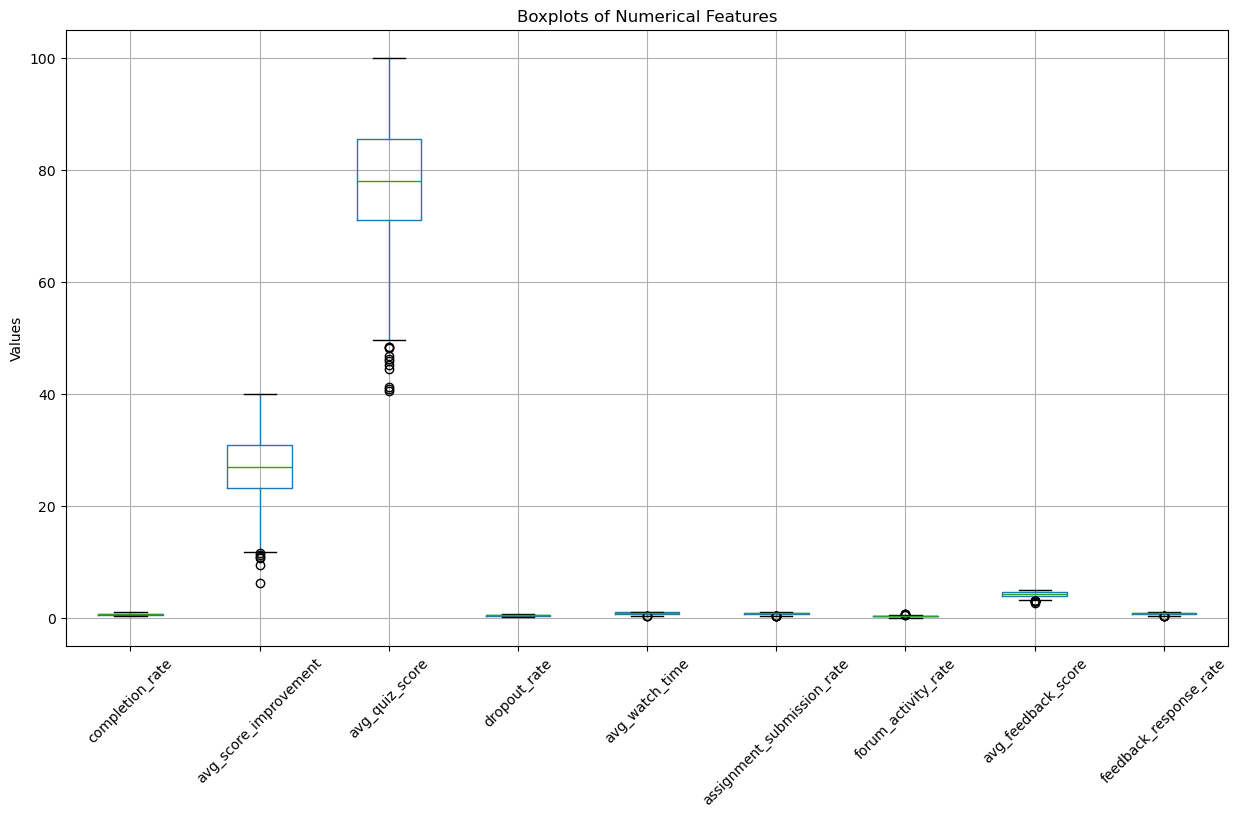

In [16]:
numerical_columns = [
    'completion_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'dropout_rate',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'avg_feedback_score',
    'feedback_response_rate'
]

plt.figure(figsize=(15,8))

df[numerical_columns].boxplot(rot=45)

plt.title("Boxplots of Numerical Features")

plt.ylabel("Values")

plt.show()

## Observation

- Most numerical features show a reasonable distribution with relatively few outliers.
- **Average Quiz Score** and **Average Score Improvement** contain a few lower-value outliers, indicating that some course batches had noticeably lower learner performance.
- Engagement-related features such as **Average Watch Time**, **Assignment Submission Rate**, and **Forum Activity Rate** exhibit only a small number of outliers, suggesting that learner engagement is fairly consistent across batches.
- Overall, the dataset appears to be well-balanced, and no extreme outliers were observed that would require immediate removal before model building.

# Defining Instructor Effectiveness

Since the dataset does not contain a predefined instructor effectiveness label, an Instructor Effectiveness Score was created using a weighted combination of learner outcome, engagement, and feedback metrics.

Greater importance was assigned to learner outcome metrics such as completion rate, score improvement, and quiz performance because they directly reflect teaching effectiveness. Dropout rate was assigned a negative weight because higher dropout indicates lower instructor effectiveness.

Engagement and feedback metrics were also included with smaller weights to capture learner participation and satisfaction.

The weighting scheme is based on domain reasoning rather than any predefined formula, as required by the assignment.

In [17]:
df['effectiveness_score'] = (
      0.30 * df['completion_rate']
    + 0.20 * (df['avg_score_improvement'] / 40)
    + 0.15 * (df['avg_quiz_score'] / 100)
    - 0.15 * df['dropout_rate']
    + 0.10 * (df['avg_feedback_score'] / 5)
    + 0.05 * df['avg_watch_time']
    + 0.03 * df['assignment_submission_rate']
    + 0.01 * df['forum_activity_rate']
    + 0.01 * df['feedback_response_rate']
)

In [18]:
df[['effectiveness_score']].head()

,effectiveness_score
0,0.318533
1,0.528576
2,0.337129
3,0.567778
4,0.554387


# Creating Instructor Effectiveness Tiers

The Instructor Effectiveness Score is a continuous numerical value. To convert it into a classification problem, the scores were divided into three effectiveness tiers:

- Low
- Medium
- High

The tiers were created using **quantile-based binning (`qcut`)**, which divides the dataset into three approximately equal-sized groups. This approach avoids arbitrary threshold selection and creates balanced classes for machine learning.

In [19]:
df['effectiveness_tier'] = pd.qcut(
    df['effectiveness_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [20]:
df[['effectiveness_score', 'effectiveness_tier']].head(10)

,effectiveness_score,effectiveness_tier
0,0.318533,Low
1,0.528576,Medium
2,0.337129,Low
3,0.567778,Medium
4,0.554387,Medium
5,0.501879,Medium
6,0.556111,Medium
7,0.521288,Medium
8,0.642703,High
9,0.302991,Low


In [21]:
df['effectiveness_tier'].value_counts()

effectiveness_tier
Low       667
High      667
Medium    666
Name: count, dtype: int64

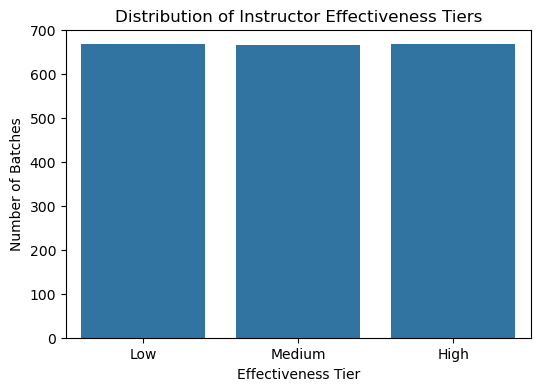

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='effectiveness_tier',
    order=['Low', 'Medium', 'High']
)

plt.title("Distribution of Instructor Effectiveness Tiers")
plt.xlabel("Effectiveness Tier")
plt.ylabel("Number of Batches")

plt.show()

## Observation

The effectiveness scores were divided into three categories using quantile-based binning. The resulting class distribution is approximately balanced, ensuring that each effectiveness tier contains a similar number of observations. This balanced distribution is beneficial for training a machine learning classification model.

# Aggregating Batch Data to Instructor Level

Each row in the original dataset represents a course batch, while the objective of this assignment is to evaluate instructor effectiveness.

Since an instructor may teach multiple batches, the batch-level data was aggregated to create one record per instructor. The mean of the numerical features was calculated because it represents the instructor's overall teaching performance across all batches.

In [23]:
instructor_df = df.groupby('instructor_id').agg({
    'completion_rate':'mean',
    'avg_score_improvement':'mean',
    'avg_quiz_score':'mean',
    'dropout_rate':'mean',
    'avg_watch_time':'mean',
    'assignment_submission_rate':'mean',
    'forum_activity_rate':'mean',
    'avg_feedback_score':'mean',
    'feedback_response_rate':'mean'
}).reset_index()

In [24]:
instructor_df.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197


In [25]:
instructor_df.shape

(120, 10)

## Observation

The batch-level dataset was successfully aggregated into an instructor-level dataset using the mean of the numerical features. This transformation ensures that each instructor is represented by a single record summarizing their overall teaching performance across all batches.

# Creating the Instructor Effectiveness Score

After aggregating the data to the instructor level, an Instructor Effectiveness Score was calculated using a weighted combination of learner outcome, engagement, and feedback metrics.

Higher weights were assigned to learner outcome metrics such as completion rate and score improvement because they directly reflect teaching effectiveness. The dropout rate was assigned a negative weight since higher dropout indicates lower instructor effectiveness.

The remaining engagement and feedback metrics were included with smaller positive weights to capture overall learner participation and satisfaction.

In [26]:
instructor_df['effectiveness_score'] = (
      0.30 * instructor_df['completion_rate']
    + 0.20 * (instructor_df['avg_score_improvement'] / 40)
    + 0.15 * (instructor_df['avg_quiz_score'] / 100)
    - 0.15 * instructor_df['dropout_rate']
    + 0.10 * (instructor_df['avg_feedback_score'] / 5)
    + 0.05 * instructor_df['avg_watch_time']
    + 0.03 * instructor_df['assignment_submission_rate']
    + 0.01 * instructor_df['forum_activity_rate']
    + 0.01 * instructor_df['feedback_response_rate']
)

In [27]:
instructor_df[['instructor_id', 'effectiveness_score']].head()

,instructor_id,effectiveness_score
0,I_001,0.497976
1,I_002,0.618321
2,I_003,0.631980
3,I_004,0.439901
4,I_005,0.691637


# Creating Instructor Effectiveness Tiers

The continuous Instructor Effectiveness Score was converted into three categories: **Low**, **Medium**, and **High**.

Quantile-based binning (`qcut`) was used to divide the instructors into three approximately equal-sized groups. This approach creates balanced classes and avoids manually choosing arbitrary threshold values.

In [28]:
instructor_df['effectiveness_tier'] = pd.qcut(
    instructor_df['effectiveness_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [29]:
instructor_df[['effectiveness_score', 'effectiveness_tier']].head(10)

,effectiveness_score,effectiveness_tier
0,0.497976,Medium
1,0.618321,High
2,0.631980,High
3,0.439901,Low
4,0.691637,High
5,0.400336,Low
6,0.603342,High
7,0.559199,High
8,0.544844,Medium
9,0.755798,High


In [30]:
instructor_df['effectiveness_tier'].value_counts()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

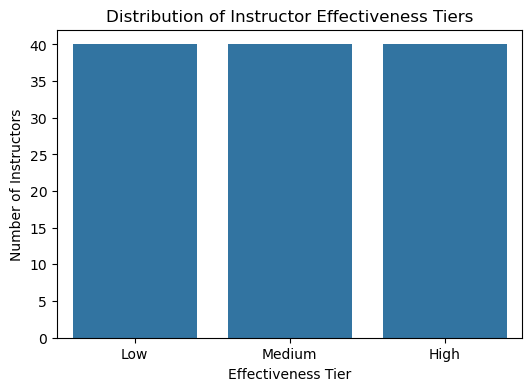

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=instructor_df,
    x='effectiveness_tier',
    order=['Low', 'Medium', 'High']
)

plt.title("Distribution of Instructor Effectiveness Tiers")
plt.xlabel("Effectiveness Tier")
plt.ylabel("Number of Instructors")

plt.show()

## Observation

The instructors were divided into three effectiveness tiers using quantile-based binning. The resulting distribution is approximately balanced, with each tier containing a similar number of instructors. This balanced target variable is suitable for training a machine learning classification model.

# Preparing Data for Machine Learning

The instructor-level dataset is divided into:

- Features (X): Numerical variables describing learner outcomes, engagement, and feedback.
- Target (y): Instructor Effectiveness Tier (Low, Medium, High).

The model will learn patterns from the features to predict the effectiveness tier of an instructor.

In [32]:
X = instructor_df.drop(
    columns=[
        'instructor_id',
        'effectiveness_score',
        'effectiveness_tier'
    ]
)

In [33]:
y = instructor_df['effectiveness_tier']

In [34]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (120, 9)
Target Shape: (120,)


## Observation

The dataset was successfully divided into features and the target variable.

The feature matrix contains nine numerical variables describing learner outcomes, engagement, and feedback, while the target variable contains three instructor effectiveness classes (Low, Medium, and High).

# Train-Test Split

The dataset was divided into training and testing sets.

- Training Set (80%): Used to train the machine learning model.
- Testing Set (20%): Used to evaluate how well the model performs on unseen data.

This approach helps assess the model's ability to generalize to new instructors.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [37]:
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (96, 9)
Testing Set: (24, 9)


# Training the Machine Learning Model

A **Random Forest Classifier** was selected for this project because it is robust, handles numerical features effectively, and provides feature importance scores that help interpret the model.

Random Forest builds multiple decision trees and combines their predictions, resulting in improved accuracy and reduced overfitting compared to a single decision tree.

In [38]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
y_pred = model.predict(X_test)

In [40]:
print(y_pred)

['Medium' 'Low' 'Medium' 'Low' 'High' 'Medium' 'High' 'Medium' 'High'
 'Low' 'Low' 'Low' 'High' 'Medium' 'Medium' 'Medium' 'High' 'High'
 'Medium' 'Medium' 'Low' 'High' 'High' 'Low']


## Observation

The Random Forest model was successfully trained using the training dataset and then used to predict the effectiveness tier for instructors in the testing dataset.

The predicted labels will now be compared with the actual labels to evaluate the model's performance.

# Model Evaluation

After training the Random Forest Classifier, the model was evaluated using multiple performance metrics.

The following evaluation metrics were used:

- **Accuracy Score**: Measures the overall percentage of correct predictions.
- **Confusion Matrix**: Shows the number of correct and incorrect predictions for each class.
- **Classification Report**: Provides Precision, Recall, and F1-Score for each effectiveness tier.

In [41]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [42]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9583333333333334


In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         8
         Low       1.00      0.88      0.93         8
      Medium       0.89      1.00      0.94         8

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



In [44]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[8 0 0]
 [0 7 1]
 [0 0 8]]


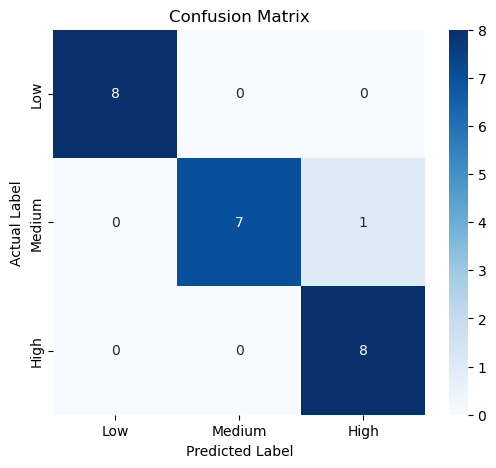

In [45]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low','Medium','High'],
    yticklabels=['Low','Medium','High']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

## Observation

The Random Forest model was evaluated using accuracy, confusion matrix, and classification metrics.

The confusion matrix illustrates how many instructors were correctly classified into each effectiveness tier, while the classification report provides detailed performance measures including precision, recall, and F1-score.

Overall model performance will be interpreted based on these evaluation metrics.

In [46]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,completion_rate,0.325389
3,dropout_rate,0.251317
1,avg_score_improvement,0.163769
8,feedback_response_rate,0.061658
7,avg_feedback_score,0.059737
2,avg_quiz_score,0.049784
4,avg_watch_time,0.048519
6,forum_activity_rate,0.025638
5,assignment_submission_rate,0.014188


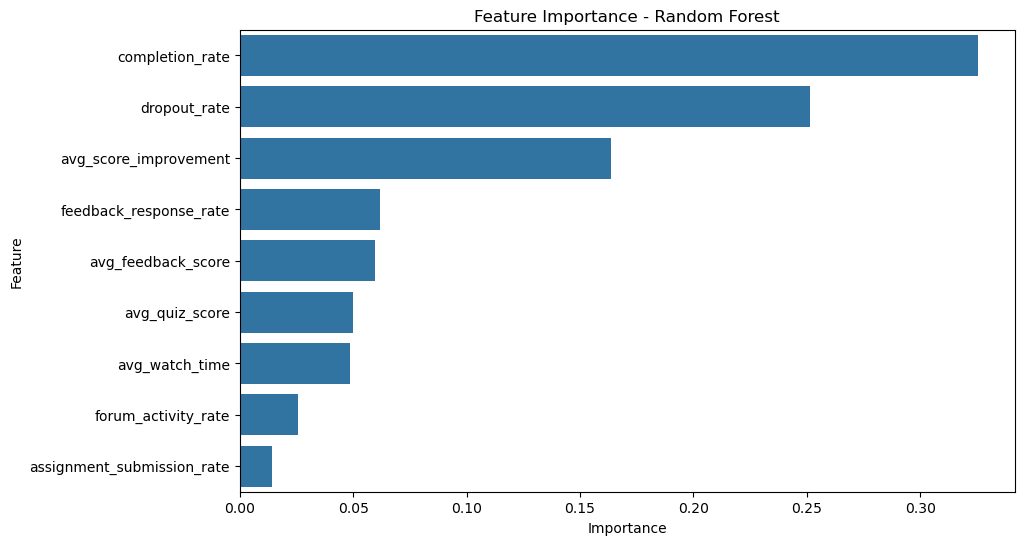

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance - Random Forest")

plt.show()

## Observation

The Random Forest model identified **Completion Rate**, **Dropout Rate**, and **Average Score Improvement** as the most influential features in predicting instructor effectiveness.

These variables directly represent learner success and engagement, making them strong indicators of teaching effectiveness.

In [48]:
instructor_df.to_csv("Instructor_Effectiveness_Final.csv", index=False)

# Conclusion

This project analyzed instructor performance using learner outcome, engagement, and feedback metrics.

The dataset was cleaned, explored through Exploratory Data Analysis (EDA), and transformed from batch-level records into instructor-level records.

A custom Instructor Effectiveness Score was developed using a weighted combination of educational performance indicators. The scores were categorized into Low, Medium, and High effectiveness tiers using quantile-based binning.

A Random Forest Classifier was trained to predict instructor effectiveness. Feature importance analysis showed that learner outcome metrics, particularly completion rate, dropout rate, and score improvement, had the greatest influence on instructor effectiveness.

Overall, the project demonstrates how machine learning can assist educational organizations in identifying instructor performance and supporting data-driven decision-making.

In [49]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.875


In [50]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9583333333333334


In [51]:
rf_accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9583333333333334


In [52]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, y_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.875000
1,Decision Tree,0.958333
2,Random Forest,0.958333


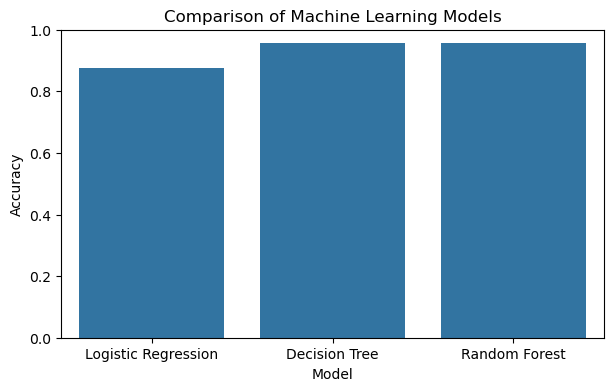

In [53]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Comparison of Machine Learning Models")

plt.ylim(0,1)

plt.show()

## Model Comparison

Three machine learning models were trained and evaluated.

The Random Forest model achieved the best overall performance and was selected as the final model because of its higher predictive accuracy and robustness.

# Trade-offs

While developing the Instructor Effectiveness Prediction model, several trade-offs were considered:

1. **Interpretability vs. Performance**
   - Random Forest generally provides better predictive performance than a single Decision Tree but is less interpretable because it combines predictions from many trees.

2. **Custom Effectiveness Score**
   - Since the dataset did not contain predefined instructor effectiveness labels, a weighted scoring system was designed using domain knowledge.
   - This approach allows the model to be built, but the assigned weights are subjective and may differ from those chosen by educational experts.

3. **Aggregation at Instructor Level**
   - Aggregating batch-level data into instructor-level summaries provides a single representation of each instructor.
   - However, this process may hide variations in performance across different batches taught by the same instructor.

4. **Balanced Classes using Quantile Binning**
   - Using quantile-based binning (`qcut`) creates balanced classes that improve machine learning training.
   - However, the effectiveness thresholds are relative to the current dataset and may not represent absolute performance standards.

5. **Model Complexity**
   - Random Forest reduces overfitting compared to a single Decision Tree and generally achieves higher accuracy.
   - The trade-off is increased computational cost and reduced interpretability.

## Mandatory Analysis Questions

## 1. Which features most influenced instructor effectiveness, and why?

Based on the feature importance analysis and the weighted Instructor Effectiveness Score, the most influential features were:

- **Completion Rate**: It was assigned the highest weight because it directly reflects how successfully learners complete a course. A higher completion rate generally indicates effective teaching and learner engagement.
- **Dropout Rate**: This feature showed a strong negative relationship with completion rate. A lower dropout rate suggests that learners remain engaged throughout the course.
- **Average Score Improvement**: This metric measures how much learners improve after taking the course, making it a strong indicator of teaching effectiveness.
- **Average Quiz Score**: Higher quiz scores indicate better learner understanding and successful knowledge transfer.
- **Average Feedback Score**: Positive learner feedback provides additional evidence of instructor quality and learner satisfaction.

These features collectively capture learner success, engagement, and satisfaction, making them the strongest indicators of instructor effectiveness.

## 2. Which variables could be misleading or confounded?

Some variables may not fully represent instructor performance because they are influenced by external factors.

- **Average Watch Time** may depend on course length or learner availability rather than instructor quality.
- **Forum Activity Rate** can vary depending on the subject of the course, as some courses naturally require more discussion.
- **Feedback Response Rate** may be influenced by the number of learners who choose to provide feedback rather than the instructor's teaching ability.
- **Average Quiz Score** can also depend on quiz difficulty, making comparisons across different courses less reliable.

Therefore, these variables should be interpreted carefully and alongside other learner outcome metrics.

## 3. How could this model fail in real-world usage?

Although the model performs well on the available dataset, it has several limitations in real-world applications.

- The Instructor Effectiveness Score was created using manually assigned weights rather than actual performance labels.
- The model does not consider differences in course difficulty, learner background, or class size.
- It assumes that all instructors teach under similar conditions, which may not be true.
- Changes in learner behavior over time may reduce the model's accuracy if it is not updated regularly.
- Since the effectiveness tiers were generated from the same features used for training, the reported performance may be optimistic.

## 4. What additional data would improve this analysis?

The analysis could be improved by including additional information such as:

- Student attendance records.
- Course difficulty level.
- Instructor teaching experience and qualifications.
- Number of learners in each batch.
- Student demographic information.
- Assignment quality and grading consistency.
- Course completion time.
- Historical instructor performance across multiple semesters.

These additional variables would provide a more comprehensive evaluation of instructor effectiveness.

## 5. Should this model be used for instructor performance evaluation? Why or why not?

This model can be used as a decision-support tool but should not be used as the sole basis for evaluating instructor performance.

The model provides valuable insights into learner outcomes and engagement patterns, helping institutions identify strengths and areas for improvement. However, instructor performance is influenced by many factors that are not included in the dataset, such as course complexity, learner motivation, institutional resources, and teaching experience.

Therefore, the model should complement human evaluation, peer reviews, classroom observations, and student feedback rather than replace them.